In [ ]:
import os
import numpy as np 
import pandas as pd
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
from zhiyi.analysis.SE_analysis import get_site_index 
from scipy.spatial import cKDTree
import string
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerTuple
print("done")

done


In [ ]:
scrip30 = xr.open_dataset("/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc")

filebase_ne30 = '/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc'         
start_date = datetime.date(2018, 5, 15)
end_date = datetime.date(2018, 6, 25)                

se_files = []
current = start_date
while current <= end_date:
    MM = current.strftime("%m")
    DD = current.strftime("%d")
    file_path = filebase_ne30.replace("MM", MM).replace("DD", DD)
    if os.path.exists(file_path):
        se_files.append(file_path)
    else:
        print(f"Files not here")
    current += datetime.timedelta(days=1)
ds_ne30 = xr.open_mfdataset(se_files, combine="by_coords")  

scrip60 = xr.open_dataset("/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc")

filebase_ne60 = '/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc'
start_date_ne60 = datetime.date(2018, 5, 15)
end_date_ne60 = datetime.date(2018, 6, 25)

se_files_ne60 = []
current_ne60 = start_date_ne60
while current_ne60 <= end_date_ne60:
    MM = current_ne60.strftime("%m")
    DD = current_ne60.strftime("%d")
    file_path_ne60 = filebase_ne60.replace("MM", MM).replace("DD", DD)
    if os.path.exists(file_path_ne60):
        se_files_ne60.append(file_path_ne60)
    else:
        print(f"Files not here")
    current_ne60 += datetime.timedelta(days=1)
ds_ne60 = xr.open_mfdataset(se_files_ne60, combine="by_coords")

print("Datasets loaded!")  

Datasets loaded!


In [ ]:
def get_region_idx(scrip):
    lon360 = scrip['grid_center_lon']
    lat    = scrip['grid_center_lat']
    lon     = ((lon360 + 180) % 360) - 180    
    mask    = (lon >= -9) & (lon <= 2) & (lat >= 49.5) & (lat <= 61.5)
    return np.where(mask.values)[0]

idx30 = get_region_idx(scrip30)
idx60 = get_region_idx(scrip60)

vars_with_lev = ['T', 'CLOUD']
vars_no_lev   = ['FSDS', 'OMEGA500', 'PRECT', 'PBLH', 'BURDENBCdn']

all_vars = vars_with_lev + vars_no_lev
mean30 = {}
mean60 = {}
for var in all_vars:
    if var in vars_with_lev:
        arr30 = ds_ne30[var].isel(lev=-1, ncol=idx30)
        arr60 = ds_ne60[var].isel(lev=-1, ncol=idx60)
    else:
        arr30 = ds_ne30[var].isel(ncol=idx30)
        arr60 = ds_ne60[var].isel(ncol=idx60)
    mean30[var] = arr30.mean(dim='ncol')
    mean60[var] = arr60.mean(dim='ncol')

# BC
g   = 9.80665 # m/s2
R_d = 287.05  # J/(kg·K)
P0  = 101325

def compute_delta_z1(ds):
    A_i = ds['hyai'] * 1000
    B_i = ds['hybi']
    PS  = P0 
    p_interface = A_i + B_i * PS 
    p0 = p_interface.isel(ilev=-2)
    p1 = p_interface.isel(ilev=-1)
    T0 = ds['T'].isel(lev=-1)
    valid = (p0 > 0) & (p1 > 0)
    delta_z1 = xr.where(
        valid,
        (R_d * T0 / g) * np.log(p1 / p0),
        np.nan
    )
    return delta_z1



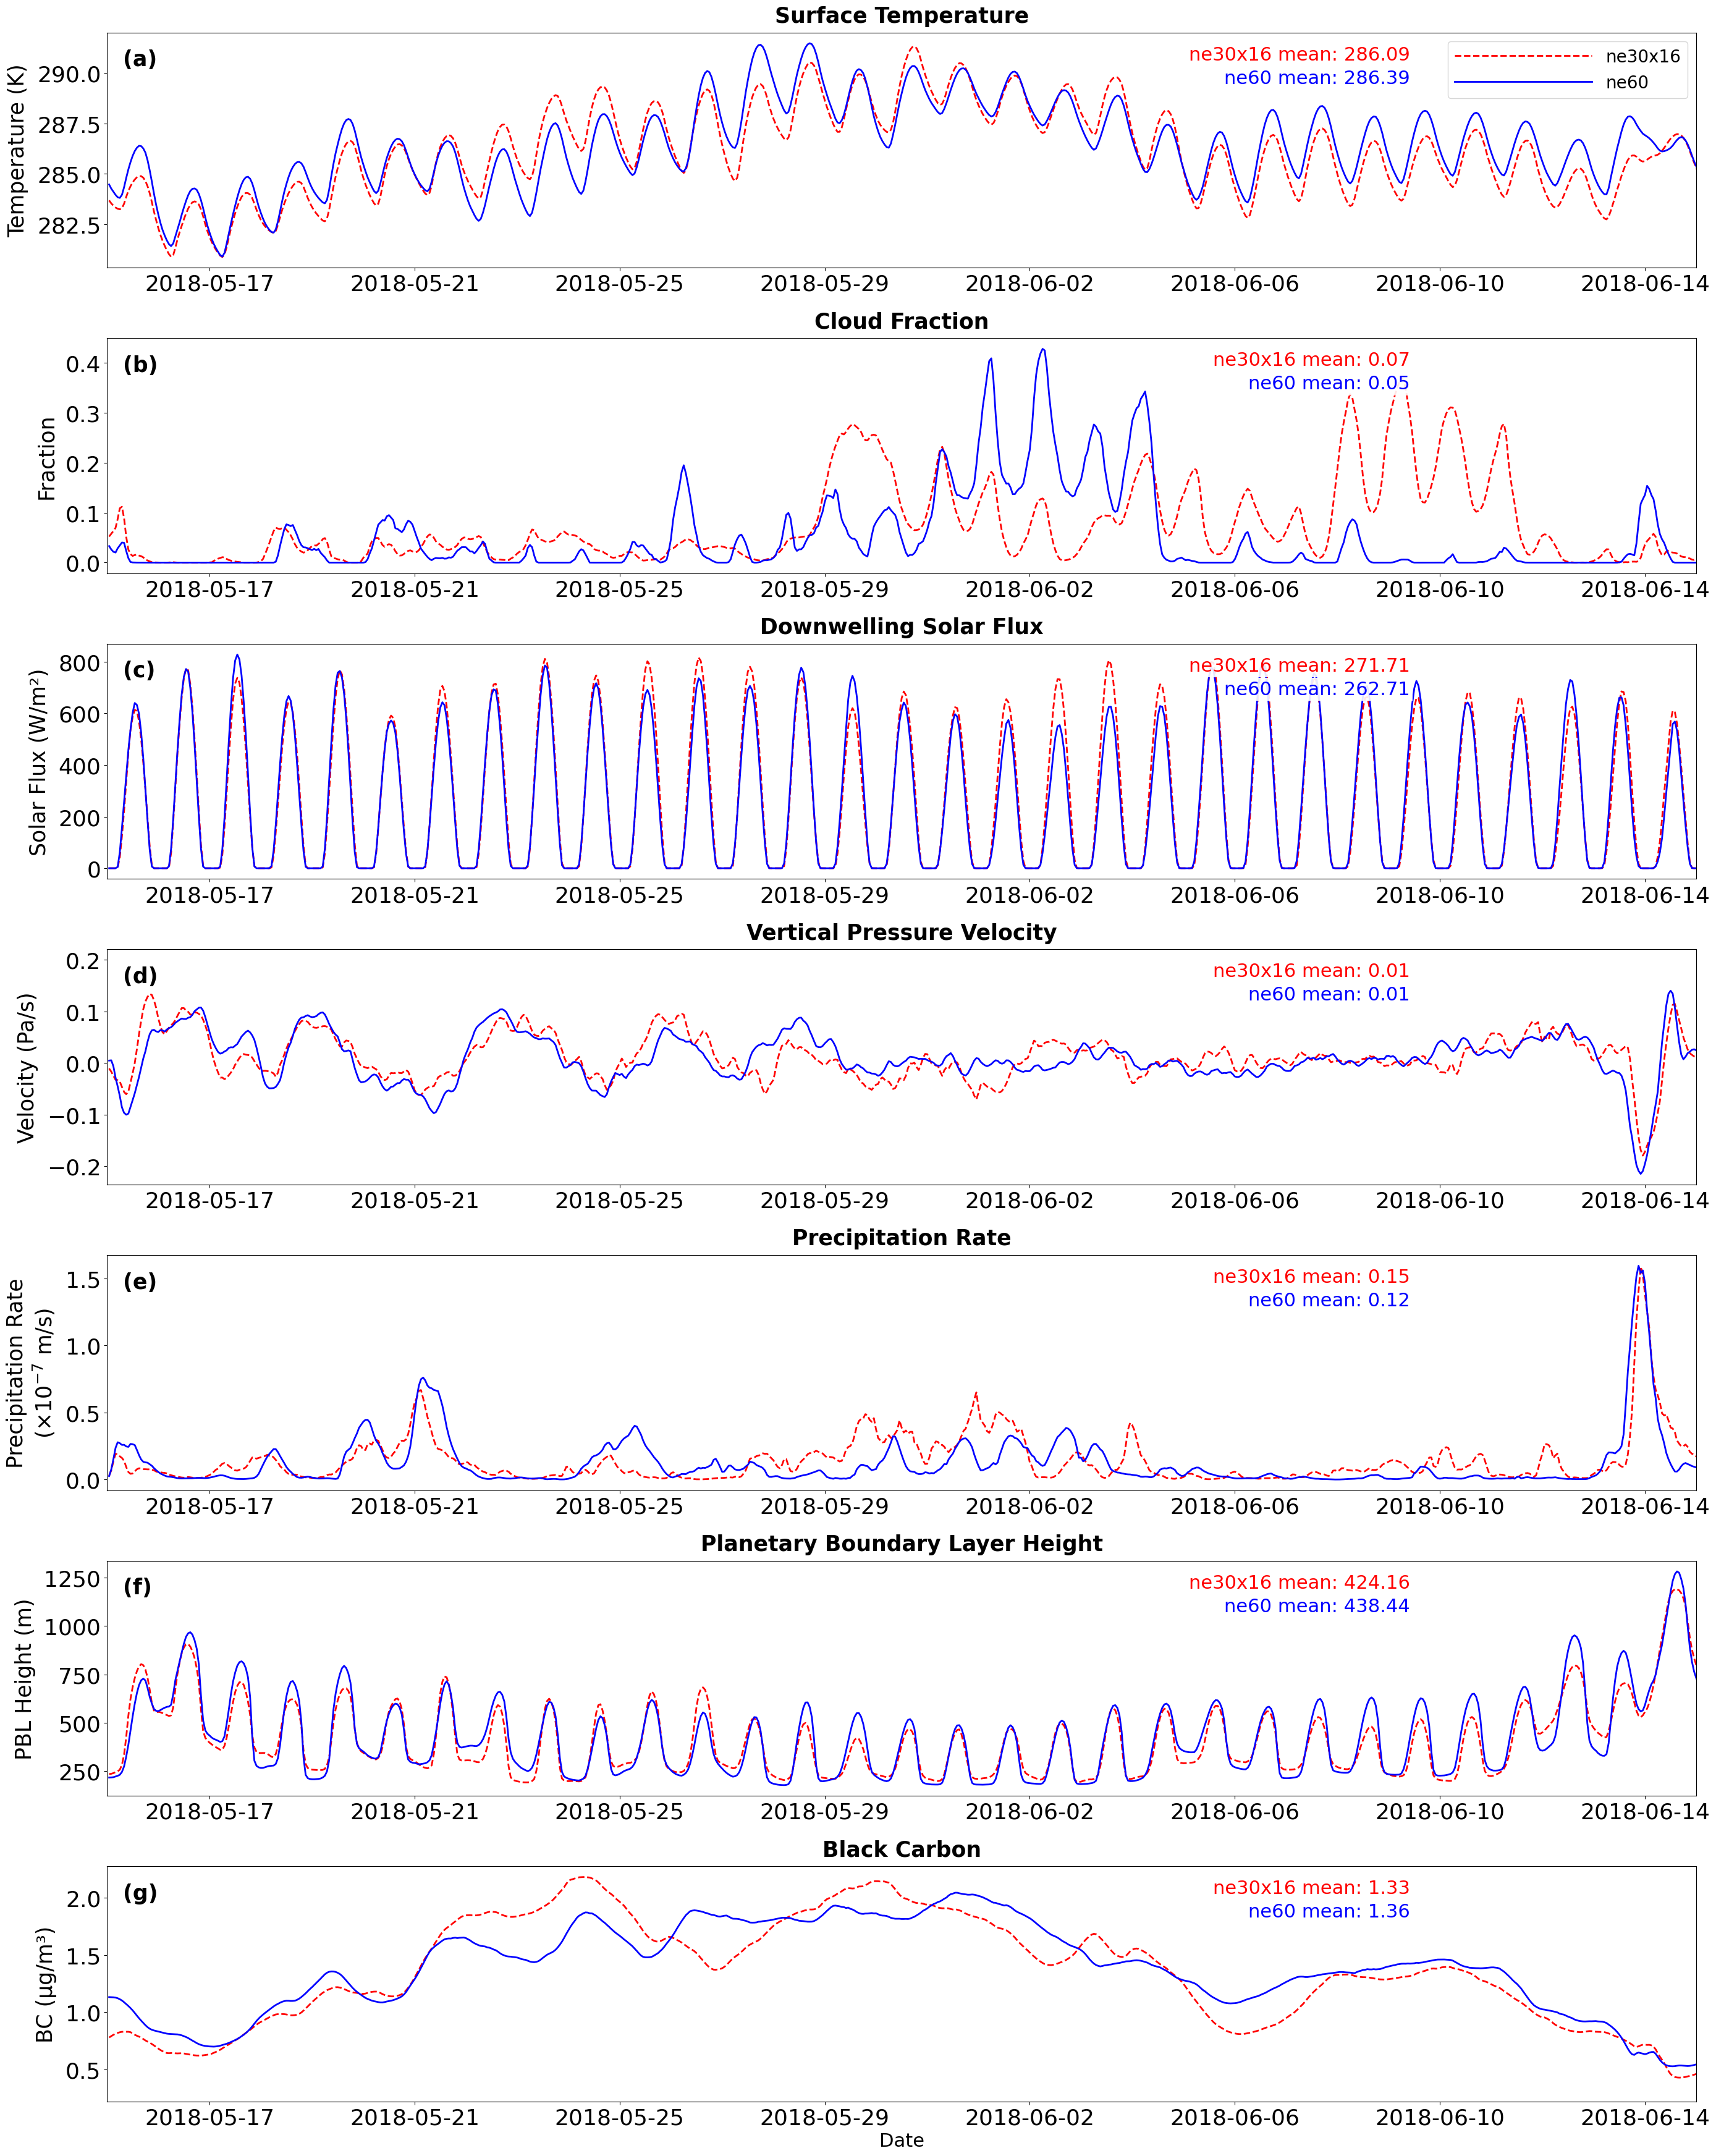

In [ ]:

titles = [
    'Surface Temperature',
    'Cloud Fraction',
    'Downwelling Solar Flux',
    'Vertical Pressure Velocity',
    'Precipitation Rate',
    'Planetary Boundary Layer Height',
    'Black Carbon']

ylabels = [
    'Temperature (K)', 
    'Fraction', 
    'Solar Flux (W/m²)',
    'Velocity (Pa/s)',
    'Precipitation Rate\n($\\times10^{-7}$ m/s)',
    'PBL Height (m)',
    'BC (µg/m³)']

letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)']
dz1_30 = compute_delta_z1(ds_ne30).isel(ncol=idx30).mean(dim='ncol')
dz1_60 = compute_delta_z1(ds_ne60).isel(ncol=idx60).mean(dim='ncol')

fig, axes = plt.subplots(nrows=len(all_vars), ncols=1, figsize=(28, 5 * len(all_vars)))
for idx, (ax, var, title, ylabel) in enumerate(zip(axes, all_vars, titles, ylabels)):
    data30 = mean30[var]
    data60 = mean60[var]
    if var == 'BURDENBCdn':
        data30 = (data30 / dz1_30) * 1e9
        data60 = (data60 / dz1_60) * 1e9
    if var == 'PRECT':
        data30 = data30 * 1e7
        data60 = data60 * 1e7       
    ax.text(0.01, 0.93, letters[idx],     
        transform=ax.transAxes,
        fontsize=25,
        fontweight='bold',
        va='top',  
        ha='left'
    )

    sel_slice = slice("2018-05-15", "2018-06-15")
    mean_val30 = float(data30.sel(time=sel_slice).mean(dim="time").values)
    mean_val60 = float(data60.sel(time=sel_slice).mean(dim="time").values)

    ax.text(
        0.82, 0.945,
        f'ne30x16 mean: {mean_val30:.2f}',
        transform=ax.transAxes,
        fontsize=22,
        color='red',
        va='top', ha='right',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=3)
    )
    ax.text(
        0.82, 0.845,
        f'ne60 mean: {mean_val60:.2f}',
        transform=ax.transAxes,
        fontsize=22,
        color='blue',
        va='top', ha='right',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=3)
    )
    ax.plot(ds_ne30.time, data30, 'r--', label='ne30x16', linewidth=2.0)
    ax.plot(ds_ne60.time, data60,  'b-', label='ne60',  linewidth=2.0)
    ax.set_title(title, fontsize=25, pad=12, weight='bold')         
    ax.set_ylabel(ylabel, fontsize=25, labelpad=10)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.set_xlim(pd.to_datetime('2018-05-15'), pd.to_datetime('2018-06-15'))
    ax.tick_params(axis='both', which='major', labelsize=26)
    if idx == 0: 
        ax.legend(fontsize=20, loc='upper right', handlelength=8)
axes[-1].set_xlabel('Date', fontsize=22)

plt.tight_layout()
fig.subplots_adjust(hspace=0.3)

